# Breakout Agent Test

This notebook runs a trained or test policy in the Atari Breakout environment and records what happens during each episode. The code creates the environment, repeatedly chooses an action from the current observation, steps the game forward, stores rewards and frames, and stops an episode when the environment reports that it has either `terminated` naturally or been `truncated` by an outside limit.

At the end of each episode, the notebook prints the total reward and saves a GIF so you can visually inspect how the agent played.

A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


Episode 1 reward total = 38.0 | saved runs/breakout-movies-20260825-224227/episode_1.gif


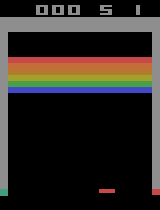

Episode 2 reward total = 25.0 | saved runs/breakout-movies-20260825-224227/episode_2.gif


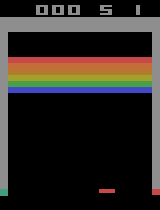

Episode 3 reward total = 11.0 | saved runs/breakout-movies-20260825-224227/episode_3.gif


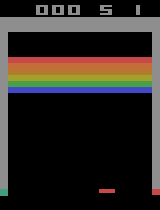

Episode 4 reward total = 33.0 | saved runs/breakout-movies-20260825-224227/episode_4.gif


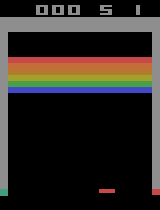

Episode 5 reward total = 34.0 | saved runs/breakout-movies-20260825-224227/episode_5.gif


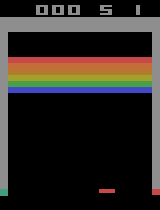

Running mean reward over 5 episodes: 28.200
All movies saved in: runs/breakout-movies-20260825-224227


In [3]:
import os, time, pickle
import numpy as np
import gymnasium as gym
import ale_py
import imageio.v2 as imageio

# If you're in a notebook and want to auto-display the movie:
try:
    from IPython.display import display, Image as IPyImage
    IN_NOTEBOOK = True
except Exception:
    IN_NOTEBOOK = False

# --------------------------
# Hyperparameters
# --------------------------
num_actions = 4
D = 80 * 80

# --------------------------
# Load trained model
# --------------------------
path = "weights_ep74900.pkl"
model = pickle.load(open(path, "rb"))

# --------------------------
# Utils
# --------------------------
def softmax(x):
    x = np.exp(x - np.max(x))
    return x / np.sum(x)

def prepro(I):
    """Preprocess 210x160x3 uint8 frame into 6400 (80x80) float vector."""
    I = I[35:195]          # crop
    I = I[::2, ::2, 0]     # downsample by factor of 2, take one channel
    I[(I == 144) | (I == 109)] = 0  # background
    I[I != 0] = 1          # paddles/ball
    return I.astype(np.float32).ravel()

def policy_forward(x):
    h = np.dot(model["W1"], x)
    h[h < 0] = 0           # ReLU
    logp = np.dot(model["W2"], h)
    p = softmax(logp)      # 4-way softmax
    return p, h

# --------------------------
# Environment
# --------------------------
env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
observation, info = env.reset(seed=42)

prev_x = None
running_reward = []
reward_sum = 0.0
episode_number = 0

# Output dir for movies
RUNSTAMP = time.strftime("%Y%m%d-%H%M%S")
OUTDIR = f"runs/breakout-movies-{RUNSTAMP}"
os.makedirs(OUTDIR, exist_ok=True)

# --------------------------
# Run and record movies
# --------------------------
while episode_number < 5:
    # Open a new writer for this episode
    # For MP4 instead of GIF, use:
    #   movie_path = os.path.join(OUTDIR, f"episode_{episode_number+1}.mp4")
    #   writer = imageio.get_writer(movie_path, fps=30)  # requires imageio-ffmpeg
    movie_path = os.path.join(OUTDIR, f"episode_{episode_number+1}.gif")
    writer = imageio.get_writer(movie_path, mode="I", fps=30)

    done = False
    while not done:
        # Render current frame (RGB array) and append to video
        frame = env.render()
        writer.append_data(frame)

        # Preprocess + policy + sample action
        cur_x = prepro(frame)
        x = cur_x - prev_x if prev_x is not None else np.zeros(D, dtype=np.float32)
        prev_x = cur_x

        aprob, _ = policy_forward(x)
        action = np.random.choice(range(num_actions), p=aprob)

        # Step env
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        reward_sum += reward

    # Close and (optionally) display the movie
    writer.close()
    episode_number += 1
    print(f"Episode {episode_number} reward total = {reward_sum:.1f} | saved {movie_path}")
    running_reward.append(reward_sum)

    if IN_NOTEBOOK:
        # Display the GIF inline in notebooks
        display(IPyImage(filename=movie_path))

    # Reset for next episode
    observation, info = env.reset()
    prev_x = None
    reward_sum = 0.0

env.close()
print(f"Running mean reward over {len(running_reward)} episodes: {np.mean(running_reward):.3f}")
print(f"All movies saved in: {OUTDIR}")
